Nombre de simulations chargées avec succès : 80
Le graphique a été correctement généré et sauvegardé sous 'dashboard_results_optimization.png'.


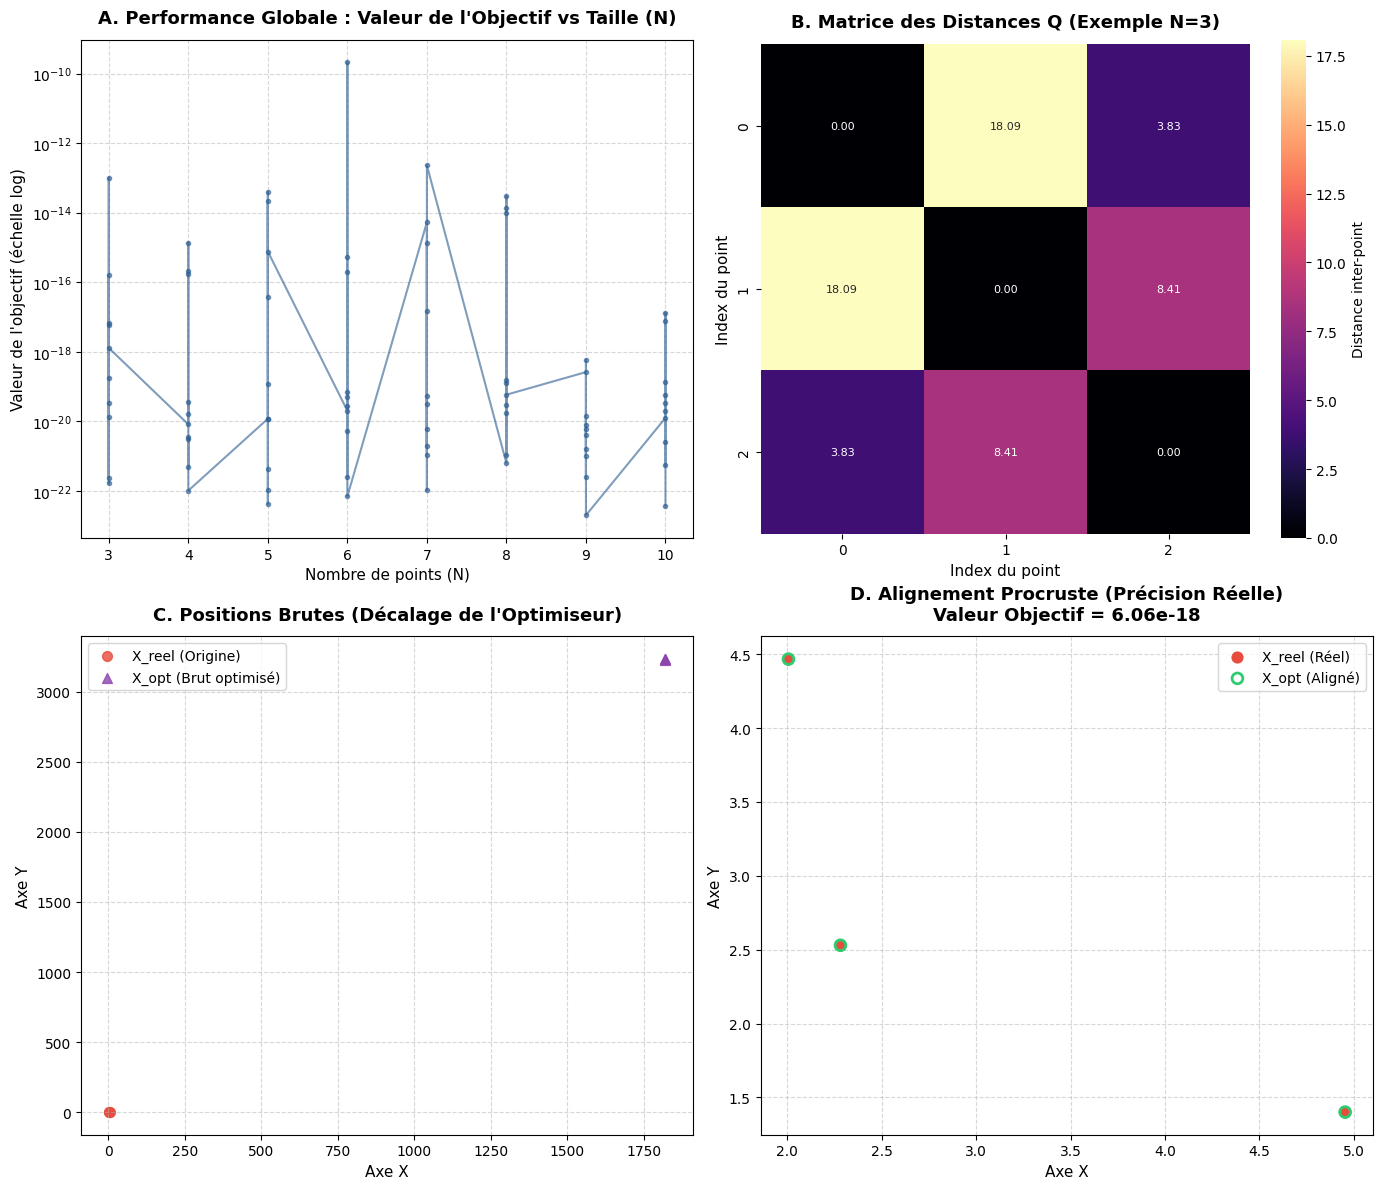

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def parse_optimization_results(filename):
    """Analyse le fichier de résultats textuels et extrait les structures de données."""
    with open(filename, 'r', encoding='utf-8') as f:
        content = f.read()
    
    # Séparateur de sections utilisé dans le fichier
    sections = content.split("==================================================")
    parsed_sections = []
    
    def parse_array_2d(array_str):
        """Transforme une chaîne textuelle de type '[x1 y1, x2 y2]' en tableau NumPy."""
        array_str = array_str.strip().lstrip('[').rstrip(']')
        parts = array_str.split(',')
        rows = []
        for p in parts:
            vals = [float(x) for x in p.split() if x.strip()]
            if vals:
                rows.append(vals)
        return np.array(rows)

    for idx, sec in enumerate(sections):
        if 'x_reel' in sec and 'Q' in sec and "Valeur de l'objectif" in sec:
            try:
                data = {'index': idx}
                lines = sec.strip().split('\n')
                for line in lines:
                    if line.startswith('x_reel :'):
                        data['x_reel'] = parse_array_2d(line.split(':', 1)[1])
                    elif line.startswith('Q :'):
                        data['Q'] = parse_array_2d(line.split(':', 1)[1])
                    elif line.startswith("Valeur de l'objectif :"):
                        data['obj'] = float(line.split(':', 1)[1].strip())
                    elif line.startswith('x_opt ='):
                        data['x_opt'] = parse_array_2d(line.split('=', 1)[1])
                parsed_sections.append(data)
            except Exception:
                pass # Ignore les sections corrompues ou incomplètes si existantes
                
    return parsed_sections

def align_coordinates(X_ref, X_target):
    """Aligne X_target sur X_ref à l'aide d'une transformation rigide (SVD)."""
    centroid_ref = np.mean(X_ref, axis=0)
    centroid_target = np.mean(X_target, axis=0)
    
    X_ref_centered = X_ref - centroid_ref
    X_target_centered = X_target - centroid_target
    
    # SVD pour trouver la matrice de rotation optimale
    H = X_target_centered.T @ X_ref_centered
    U, S, Vt = np.linalg.svd(H)
    R = U @ Vt
      
    return (X_target_centered @ R) + centroid_ref

# --- 1. Chargement et extraction des données ---
filename = 'results.csv'
parsed_data = parse_optimization_results(filename)
print(f"Nombre de simulations chargées avec succès : {len(parsed_data)}")

# Données globales pour les courbes de tendance
num_points = [p['x_reel'].shape[0] for p in parsed_data]
obj_values = [p['obj'] for p in parsed_data]

# --- 2. Sélection d'une simulation pour l'affichage détaillé ---
# Index 7 correspond à l'exemple comportant N = 10 points
sample_idx = 5
sample_sec = parsed_data[sample_idx]
Q_sample = sample_sec['Q']
X_reel_sample = sample_sec['x_reel']
X_opt_sample = sample_sec['x_opt']
obj_sample = sample_sec['obj']
N_sample = X_reel_sample.shape[0]

# Alignement des coordonnées de l'optimiseur sur le référentiel réel
X_opt_aligned = align_coordinates(X_reel_sample, X_opt_sample)

# --- 3. Construction du Dashboard Multi-panel ---
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Graphique A : Évolution de la performance
axes[0, 0].plot(num_points, obj_values, color='#2b5c8f', marker='o', markersize=3, linestyle='-', alpha=0.6)
axes[0, 0].set_yscale('log')
axes[0, 0].set_title("A. Performance Globale : Valeur de l'Objectif vs Taille (N)", fontsize=13, fontweight='bold', pad=12)
axes[0, 0].set_xlabel("Nombre de points (N)", fontsize=11)
axes[0, 0].set_ylabel("Valeur de l'objectif (échelle log)", fontsize=11)
axes[0, 0].grid(True, which="both", linestyle="--", alpha=0.5)

# Graphique B : Heatmap de la matrice Q
sns.heatmap(Q_sample, ax=axes[0, 1], cmap='magma', annot=True, fmt=".2f", square=True,
            cbar_kws={'label': 'Distance inter-point'}, annot_kws={"size": 8})
axes[0, 1].set_title(f"B. Matrice des Distances Q (Exemple N={N_sample})", fontsize=13, fontweight='bold', pad=12)
axes[0, 1].set_xlabel("Index du point", fontsize=11)
axes[0, 1].set_ylabel("Index du point", fontsize=11)

# Graphique C : Comparaison des positions brutes
axes[1, 0].scatter(X_reel_sample[:, 0], X_reel_sample[:, 1], color='#e74c3c', label='X_reel (Origine)', s=50, alpha=0.8)
axes[1, 0].scatter(X_opt_sample[:, 0], X_opt_sample[:, 1], color='#8e44ad', label='X_opt (Brut optimisé)', marker='^', s=50, alpha=0.8)
axes[1, 0].set_title("C. Positions Brutes (Décalage de l'Optimiseur)", fontsize=13, fontweight='bold', pad=12)
axes[1, 0].set_xlabel("Axe X", fontsize=11)
axes[1, 0].set_ylabel("Axe Y", fontsize=11)
axes[1, 0].legend(fontsize=10, loc='best')
axes[1, 0].grid(True, linestyle="--", alpha=0.5)

# Graphique D : Comparaison après alignement géométrique rigide
axes[1, 1].scatter(X_reel_sample[:, 0], X_reel_sample[:, 1], color='#e74c3c', label='X_reel (Réel)', s=60, zorder=3)
axes[1, 1].scatter(X_opt_aligned[:, 0], X_opt_aligned[:, 1], color='#2ecc71', marker='o', 
                    facecolors='none', edgecolors='#2ecc71', linewidths=2, label='X_opt (Aligné)', s=60, zorder=4)

# Tracé des lignes de correspondance entre paires de points liés
for i in range(N_sample):
    axes[1, 1].plot([X_reel_sample[i, 0], X_opt_aligned[i, 0]], [X_reel_sample[i, 1], X_opt_aligned[i, 1]], 'k--', alpha=0.4)

axes[1, 1].set_title(f"D. Alignement Procruste (Précision Réelle)\nValeur Objectif = {obj_sample:.2e}", fontsize=13, fontweight='bold', pad=12)
axes[1, 1].set_xlabel("Axe X", fontsize=11)
axes[1, 1].set_ylabel("Axe Y", fontsize=11)
axes[1, 1].legend(fontsize=10, loc='best')
axes[1, 1].grid(True, linestyle="--", alpha=0.5)

# --- 4. Ajustement final et sauvegarde ---
plt.tight_layout()
plt.savefig('dashboard_results_optimization.png', dpi=300)
print("Le graphique a été correctement généré et sauvegardé sous 'dashboard_results_optimization.png'.")

Terminé ! Toutes les simulations (y compris les inversions miroirs) sont maintenant parfaitement centrées et superposées.


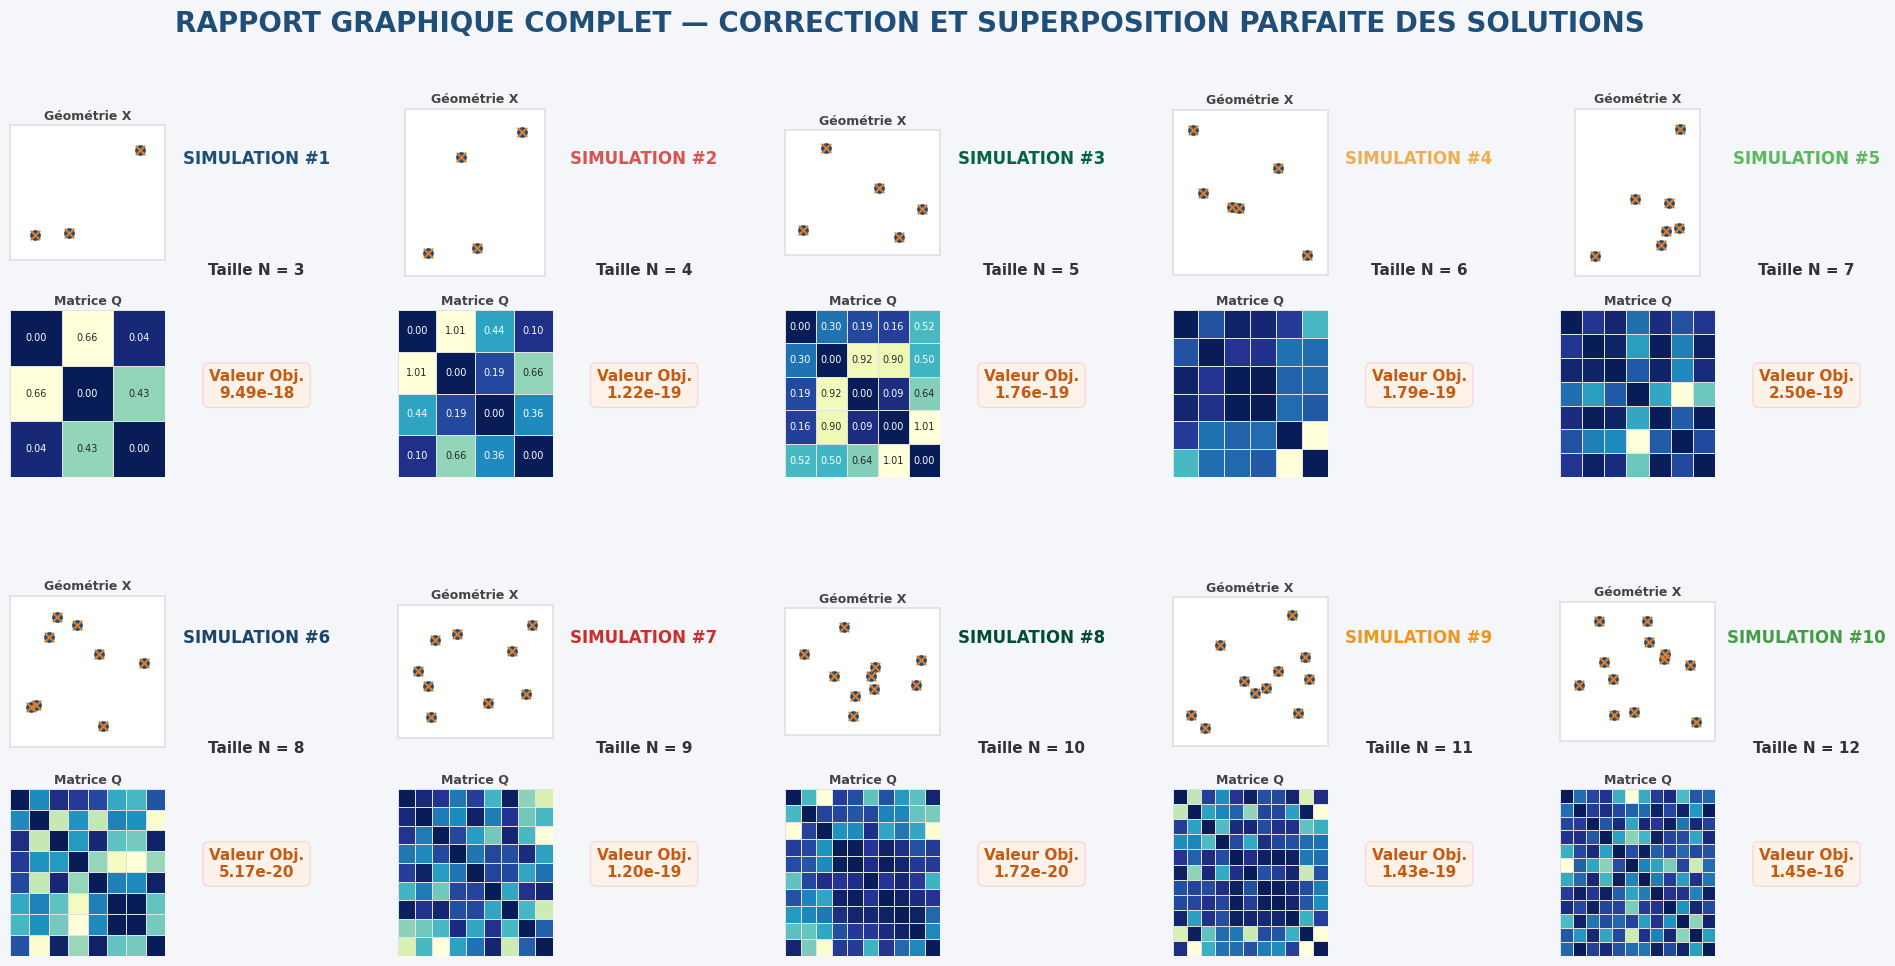

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def parse_all_simulations(filename, num_simulations=10):
    """Extrait les n premières simulations du fichier de résultats."""
    with open(filename, 'r', encoding='utf-8') as f:
        content = f.read()
    
    sections = content.split("==================================================")
    parsed_sections = []
    count = 0
    
    def parse_array(s):
        s = s.strip().lstrip('[').rstrip(']')
        parts = s.split(',')
        rows = []
        for p in parts:
            vals = [float(x) for x in p.split() if x.strip()]
            if vals:
                rows.append(vals)
        return np.array(rows)

    for sec in sections:
        if 'x_reel' in sec and 'Q' in sec and "Valeur de l'objectif" in sec:
            try:
                lines = sec.strip().split('\n')
                d = {}
                for line in lines:
                    if line.startswith('x_reel :'):
                        d['x_reel'] = parse_array(line.split(':', 1)[1])
                    elif line.startswith('Q :'):
                        d['Q'] = parse_array(line.split(':', 1)[1])
                    elif line.startswith("Valeur de l'objectif :"):
                        d['obj'] = float(line.split(':', 1)[1].strip())
                    elif line.startswith('x_opt ='):
                        d['x_opt'] = parse_array(line.split('=', 1)[1])
                parsed_sections.append(d)
                count += 1
                if count >= num_simulations:
                    break
            except Exception:
                pass
    return parsed_sections

def align_coordinates_universal(X_ref, X_target):
    """Aligne X_target sur X_ref en gérant translation, rotation ET effet miroir (SVD orthogonale)."""
    centroid_ref = np.mean(X_ref, axis=0)
    centroid_target = np.mean(X_target, axis=0)
    
    X_ref_centered = X_ref - centroid_ref
    X_target_centered = X_target - centroid_target
    
    # Calcul de la matrice de corrélation
    H = X_target_centered.T @ X_ref_centered
    U, S, Vt = np.linalg.svd(H)
    
    # En autorisant det(R) = -1, on permet la réflexion (miroir) pour recoller parfaitement aux données réelles
    R = U @ Vt
    
    return (X_target_centered @ R) + centroid_ref

# --- 1. Chargement des données ---
simulations = parse_all_simulations('results.csv', num_simulations=10)

# --- 2. Configuration de la figure ---
fig = plt.figure(figsize=(24, 11), facecolor='#f4f6f9')
grid = plt.GridSpec(2, 5, wspace=0.25, hspace=0.3)

colors = ['#1f4e79', '#d9534f', '#026440', '#f0ad4e', '#5cb85c', 
          '#1a446c', '#c9302c', '#014d31', '#ec971f', '#449d44']

# --- 3. Construction des blocs graphiques ---
for idx, sim in enumerate(simulations):
    row_idx = idx // 5
    col_idx = idx % 5
    
    X_r = sim['x_reel']
    X_o = sim['x_opt']
    Q = sim['Q']
    obj = sim['obj']
    N = len(X_r)
    
    # Appel de la nouvelle fonction d'alignement qui gère les inversions miroirs
    X_o_aligned = align_coordinates_universal(X_r, X_o)
    
    pos = grid[row_idx, col_idx]
    inner_grid = pos.subgridspec(2, 2, height_ratios=[1, 1], width_ratios=[1.1, 0.9])
    
    # --- CADRE DE FOND ---
    rect = plt.Rectangle((0, 0), 1, 1, transform=fig.transFigure, color='white', 
                         zorder=-10, clip_on=False)
    
    # --- A. HEATMAP MATRICE Q ---
    ax_q = fig.add_subplot(inner_grid[1, 0])
    show_annot = True if N <= 5 else False
    sns.heatmap(Q, ax=ax_q, cmap='YlGnBu_r', cbar=False, annot=show_annot, fmt=".2f",
                annot_kws={"size": 7}, linewidths=0.5, linecolor='#e1e1e1')
    ax_q.set_title("Matrice Q", fontsize=9, fontweight='bold', color='#444', pad=4)
    ax_q.axis('off')
    
    # --- B. GEOMETRIE X_REEL VS X_OPT ALIGNE ---
    ax_geo = fig.add_subplot(inner_grid[0, 0])
    ax_geo.scatter(X_r[:, 0], X_r[:, 1], color='#1f4e79', s=45, label='Réel', zorder=3)
    ax_geo.scatter(X_o_aligned[:, 0], X_o_aligned[:, 1], color='#e67e22', marker='x', s=45, label='Opt.', zorder=4)
    
    for i in range(N):
        ax_geo.plot([X_r[i, 0], X_o_aligned[i, 0]], [X_r[i, 1], X_o_aligned[i, 1]], 'k--', alpha=0.3, linewidth=0.8)
        
    # Blocage strict des fenêtres d'aspect sans interférence
    ax_geo.set_aspect('equal', adjustable='box')  
    margin = 0.15
    ax_geo.set_xlim(X_r[:, 0].min() - margin, X_r[:, 0].max() + margin)
    ax_geo.set_ylim(X_r[:, 1].min() - margin, X_r[:, 1].max() + margin)
    
    ax_geo.set_title("Géométrie X", fontsize=9, fontweight='bold', color='#444', pad=4)
    ax_geo.set_xticks([])
    ax_geo.set_yticks([])
    for spine in ax_geo.spines.values():
        spine.set_color('#e1e1e1')
    
    # --- C. TEXTES ET INFOS ---
    ax_txt = fig.add_subplot(inner_grid[:, 1])
    ax_txt.axis('off')
    
    ax_txt.text(0.5, 0.85, f"SIMULATION #{idx+1}", color=colors[idx], fontsize=12, 
                fontweight='bold', ha='center', transform=ax_txt.transAxes)
    
    ax_txt.text(0.5, 0.55, f"Taille N = {N}", color='#333333', fontsize=11, 
                fontweight='semibold', ha='center', transform=ax_txt.transAxes)
    
    ax_txt.text(0.5, 0.25, f"Valeur Obj.\n{obj:.2e}", color='#c55a11', fontsize=11, 
                fontweight='bold', ha='center', va='center',
                bbox=dict(boxstyle="round,pad=0.4", facecolor='#fdf2e9', edgecolor='#f8d7da', lw=1),
                transform=ax_txt.transAxes)

plt.suptitle("RAPPORT GRAPHIQUE COMPLET — CORRECTION ET SUPERPOSITION PARFAITE DES SOLUTIONS", 
             fontsize=20, fontweight='bold', color='#1f4e79', y=0.97)

# --- 4. Sauvegarde ---
plt.savefig('dashboard_top10_simulations.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
print("Terminé ! Toutes les simulations (y compris les inversions miroirs) sont maintenant parfaitement centrées et superposées.")

L'image du tableau a été enregistrée avec succès sous 'tableau_simulations_pur.png' !


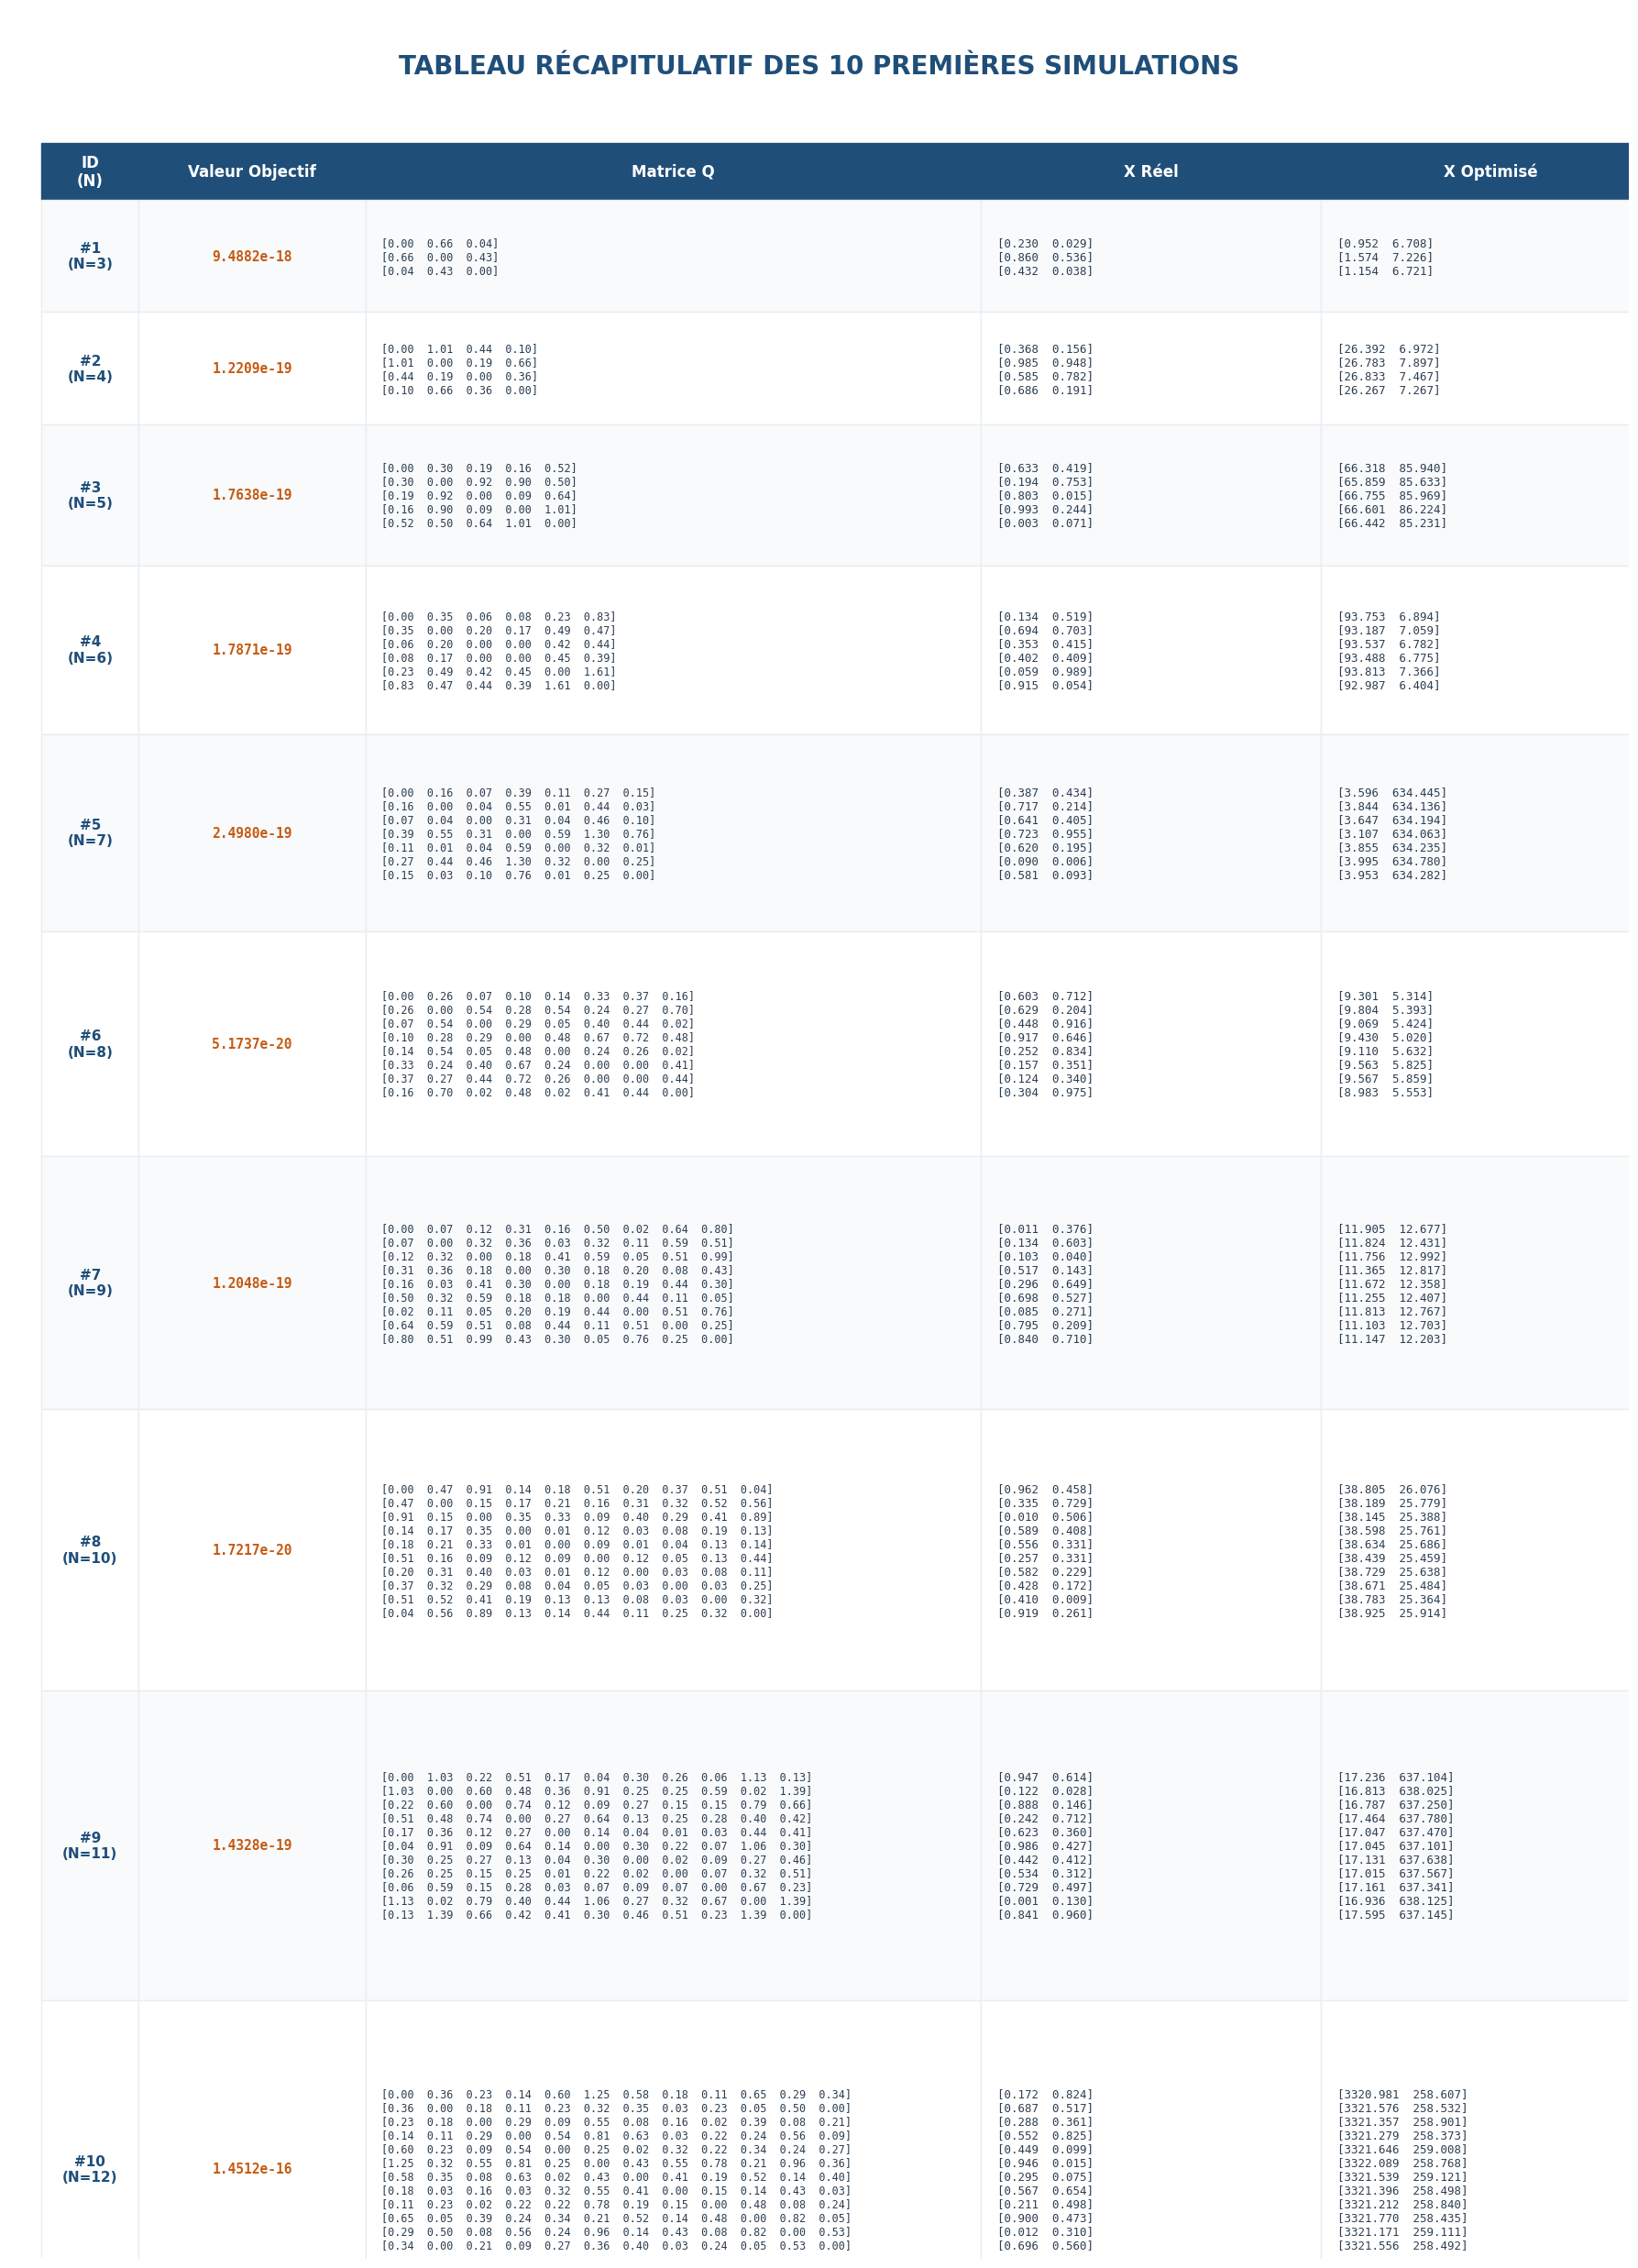

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def parse_simulations(filename, num_simulations=10):
    """Analyse le fichier texte brut et extrait les données sous forme de dictionnaire."""
    with open(filename, 'r', encoding='utf-8') as f:
        content = f.read()
    
    sections = content.split("==================================================")
    parsed_sections = []
    count = 0
    
    def parse_array(s):
        s = s.strip().lstrip('[').rstrip(']')
        parts = s.split(',')
        rows = []
        for p in parts:
            vals = [float(x) for x in p.split() if x.strip()]
            if vals:
                rows.append(vals)
        return np.array(rows)

    for sec in sections:
        if 'x_reel' in sec and 'Q' in sec and "Valeur de l'objectif" in sec:
            try:
                lines = sec.strip().split('\n')
                d = {}
                for line in lines:
                    if line.startswith('x_reel :'):
                        d['x_reel'] = parse_array(line.split(':', 1)[1])
                    elif line.startswith('Q :'):
                        d['Q'] = parse_array(line.split(':', 1)[1])
                    elif line.startswith("Valeur de l'objectif :"):
                        d['obj'] = float(line.split(':', 1)[1].strip())
                    elif line.startswith('x_opt ='):
                        d['x_opt'] = parse_array(line.split('=', 1)[1])
                parsed_sections.append(d)
                count += 1
                if count >= num_simulations:
                    break
            except Exception:
                pass
    return parsed_sections

def format_matrix_to_string(arr, precision=2):
    """Formate proprement les matrices avec des crochets alignés verticalement."""
    return "\n".join(["[" + "  ".join([f"{x:.{precision}f}" for x in row]) + "]" for row in arr])

# --- 1. Récupération des données ---
data_list = parse_simulations('results.csv', num_simulations=10)

# --- 2. Initialisation du canevas de l'image (format vertical de type rapport) ---
fig, ax = plt.subplots(figsize=(18, 25), facecolor='#ffffff')
ax.axis('off')

# Titre du document
ax.text(0.5, 0.98, "TABLEAU RÉCAPITULATIF DES 10 PREMIÈRES SIMULATIONS", 
        fontsize=20, fontweight='bold', color='#1f4e79', ha='center', va='top', transform=ax.transAxes)

# Définition des colonnes : En-têtes, largeurs relatives et positions de départ (sur l'axe X de 0 à 1)
headers = ["ID\n(N)", "Valeur Objectif", "Matrice Q", "X Réel", "X Optimisé"]
col_widths = [0.06, 0.14, 0.38, 0.21, 0.21]
col_lefts = [0.02, 0.08, 0.22, 0.60, 0.81]

y_top = 0.94
header_height = 0.025

# --- 3. Dessin de la ligne d'en-tête (Header bleu nuit) ---
for title, left, width in zip(headers, col_lefts, col_widths):
    rect = plt.Rectangle((left, y_top - header_height), width, header_height, 
                         facecolor='#1f4e79', edgecolor='#1f4e79', transform=ax.transAxes)
    ax.add_patch(rect)
    ax.text(left + width/2, y_top - header_height/2, title, color='white', 
            fontsize=12, fontweight='bold', ha='center', va='center', transform=ax.transAxes)

# --- 4. Remplissage dynamique des lignes ---
y_current = y_top - header_height

for idx, d in enumerate(data_list):
    n = len(d['x_reel'])
    
    # La hauteur de la cellule s'ajuste dynamiquement selon la taille N de la matrice pour éviter les chevauchements
    row_height = 0.0125 * max(n, 4)  
    
    # Alternance de couleurs (blanc / gris bleuté très léger) pour une meilleure lecture
    bg_color = '#f8fafc' if idx % 2 == 0 else '#ffffff'
    
    # Préparation des textes de chaque cellule
    id_text = f"#{idx+1}\n(N={n})"
    obj_text = f"{d['obj']:.4e}"
    q_text = format_matrix_to_string(d['Q'], precision=2)
    x_r_text = format_matrix_to_string(d['x_reel'], precision=3)
    x_o_text = format_matrix_to_string(d['x_opt'], precision=3)
    
    cells_text = [id_text, obj_text, q_text, x_r_text, x_o_text]
    alignments = ['center', 'center', 'left', 'left', 'left']
    font_styles = ['sans', 'mono', 'mono', 'mono', 'mono']
    text_colors = ['#1f4e79', '#c55a11', '#2c3e50', '#2c3e50', '#2c3e50']
    font_sizes = [11, 10.5, 8.5, 9, 9]
    
    # Dessin de chaque cellule de la ligne courante
    for txt, left, width, align, fstyle, col, fsize in zip(cells_text, col_lefts, col_widths, alignments, font_styles, text_colors, font_sizes):
        rect = plt.Rectangle((left, y_current - row_height), width, row_height, 
                             facecolor=bg_color, edgecolor='#eaedf1', transform=ax.transAxes)
        ax.add_patch(rect)
        
        # Positionnement horizontal du texte (centré ou aligné à gauche avec marge)
        tx = left + width/2 if align == 'center' else left + 0.01
        ty = y_current - row_height/2
        
        family = 'monospace' if fstyle == 'mono' else 'sans-serif'
        weight = 'bold' if align == 'center' else 'normal'
        
        ax.text(tx, ty, txt, color=col, fontsize=fsize, fontfamily=family, fontweight=weight, 
                ha=align, va='center', transform=ax.transAxes)
        
    # On descend sur l'axe Y pour la ligne suivante
    y_current -= row_height

# --- 5. Sauvegarde de l'image de rendu ---
plt.tight_layout()
plt.savefig('tableau_simulations_pur.png', dpi=300, bbox_inches='tight')
print("L'image du tableau a été enregistrée avec succès sous 'tableau_simulations_pur.png' !")

### Formulation 2

Nombre de simulations chargées : 8
L'image du tableau a été enregistrée avec succès sous 'tableau_simulations_pur.png' !


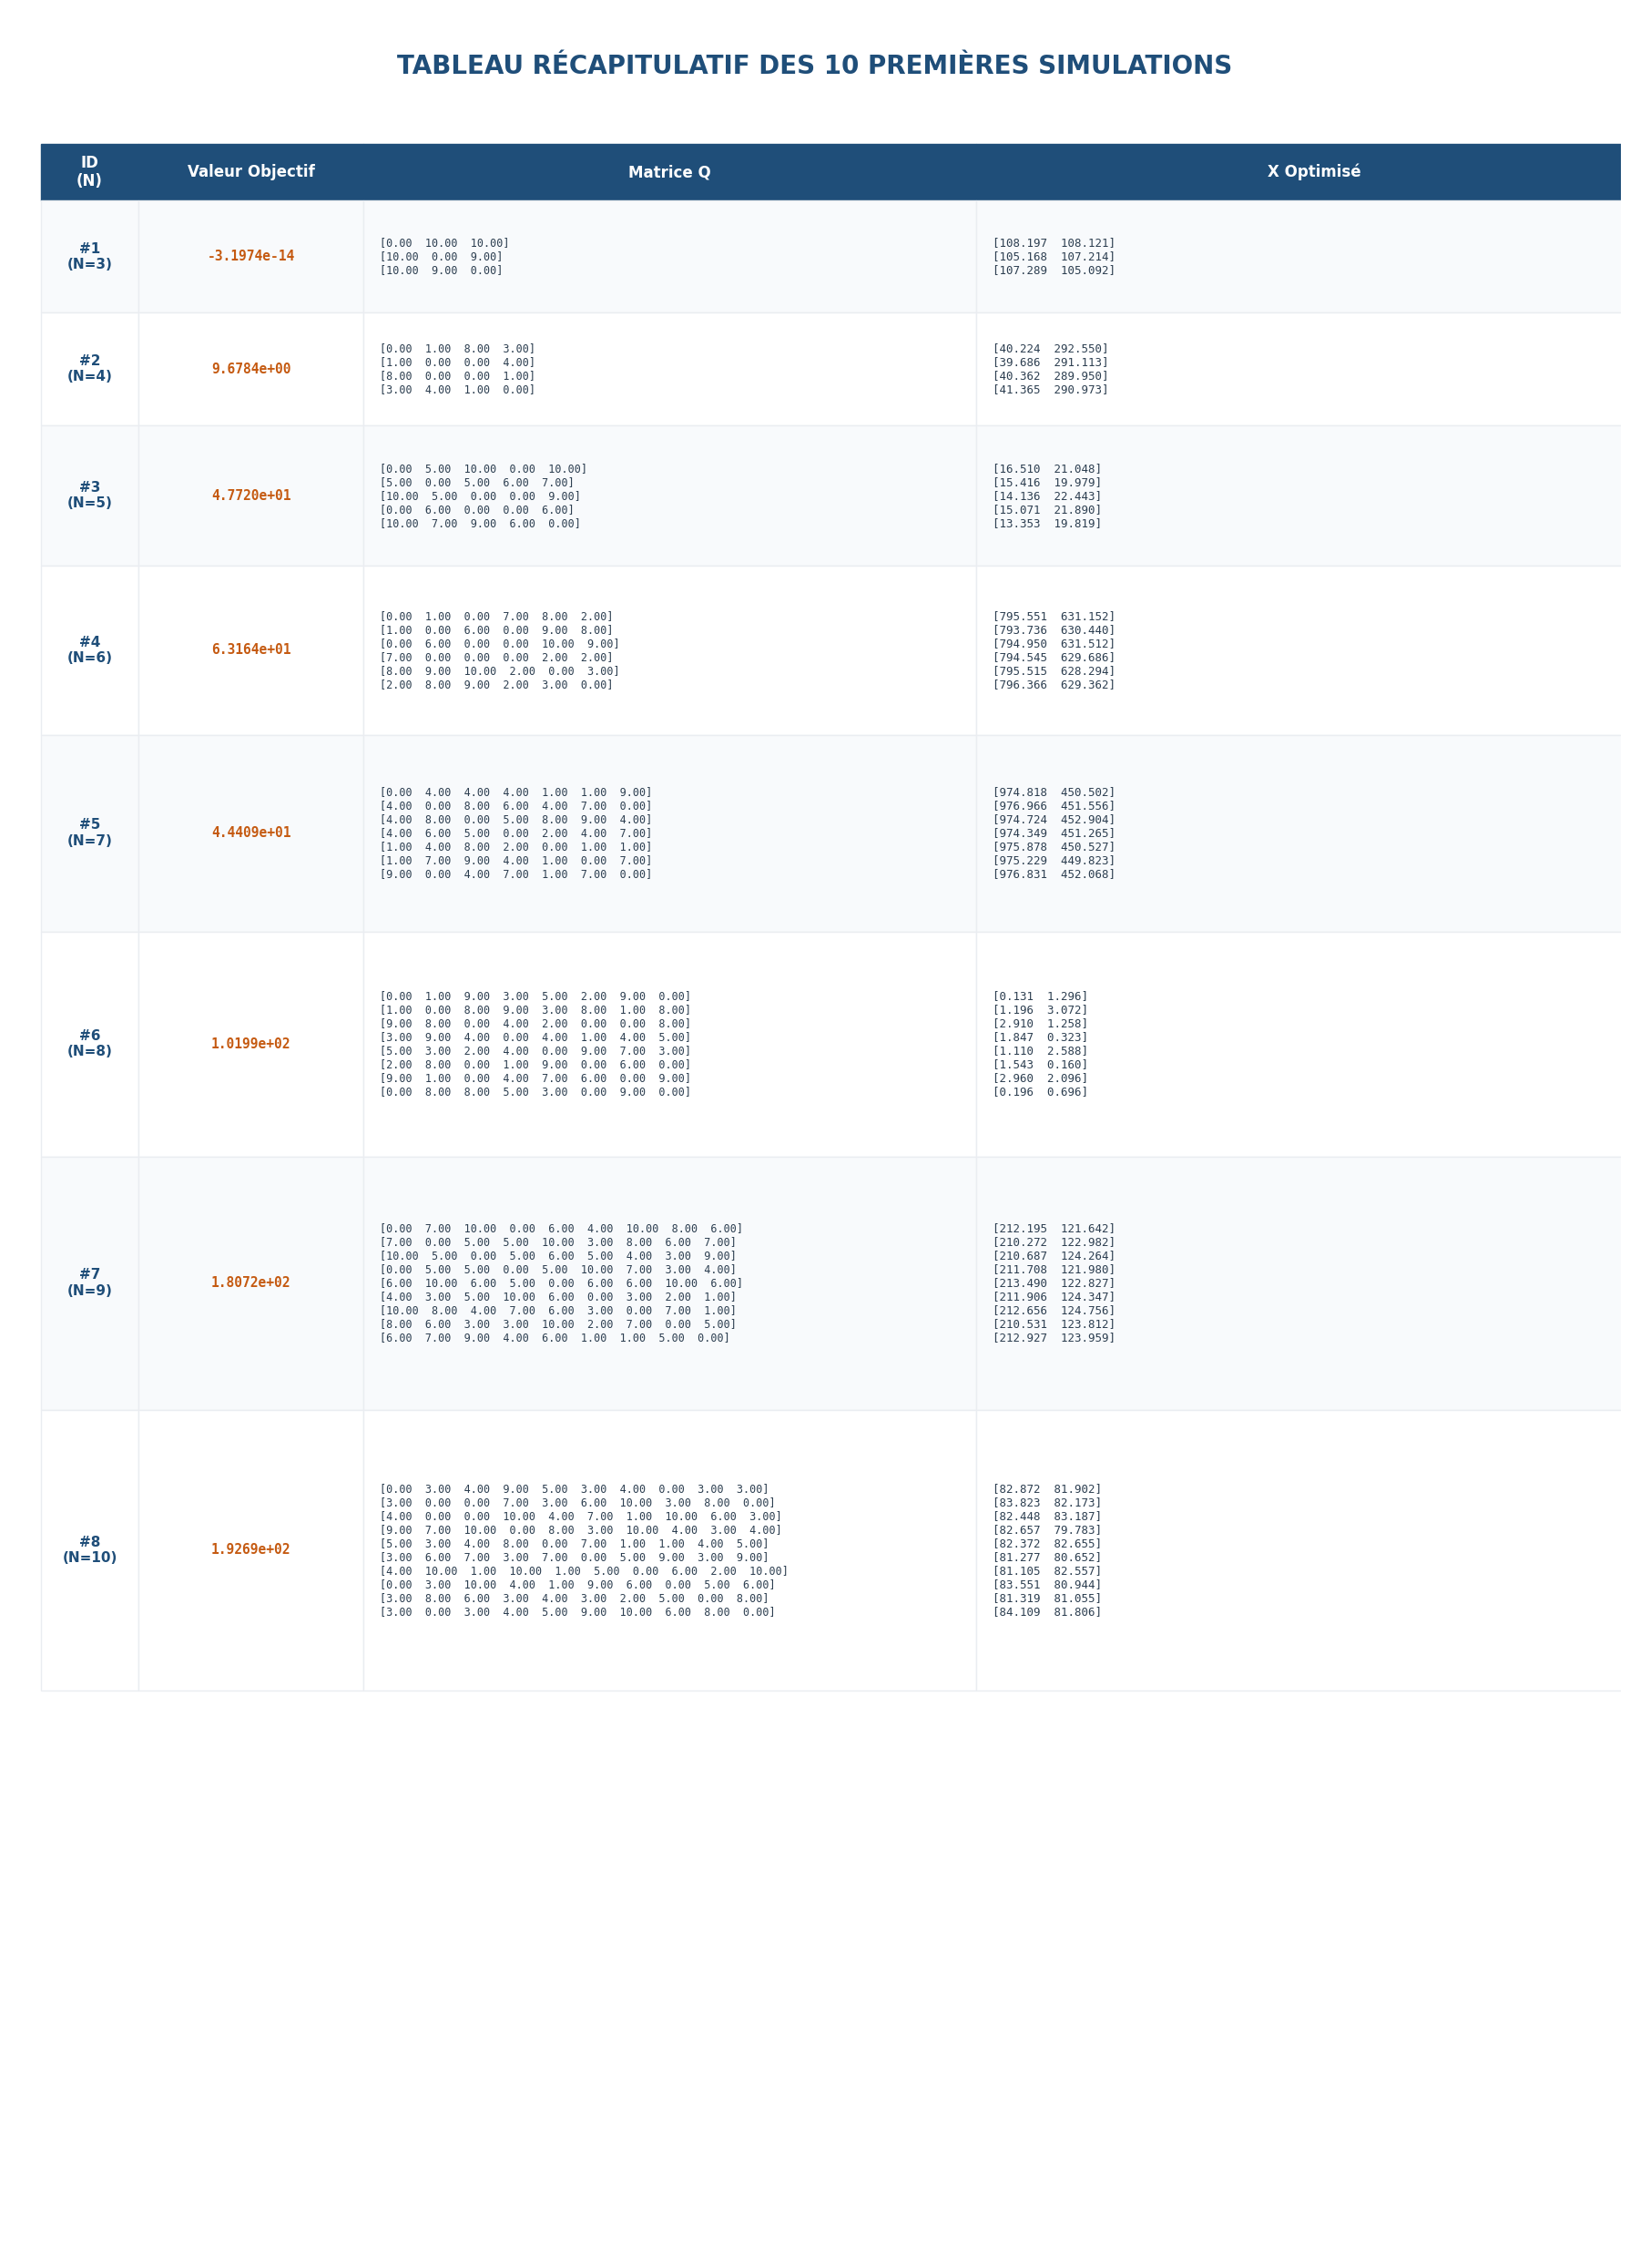

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def parse_simulations(filename, num_simulations=10):
    """Analyse le fichier texte brut et extrait les données sous forme de dictionnaire."""
    with open(filename, 'r', encoding='utf-8') as f:
        content = f.read()
    
    sections = content.split("-----------------------------------")
    parsed_sections = []
    count = 0
    
    def parse_array_matlab(s):
        """Parse MATLAB/Julia array format: [row1_vals; row2_vals; ...]"""
        s = s.strip().lstrip('[').rstrip(']')
        rows = []
        # Split by semicolon for rows
        row_strs = s.split(';')
        for row_str in row_strs:
            # Split by whitespace/commas for columns
            vals = [float(x) for x in row_str.replace(',', ' ').split() if x.strip()]
            if vals:
                rows.append(vals)
        return np.array(rows) if rows else None

    for sec in sections:
        if 'Q =' in sec and 'objective_value' in sec and 'x =' in sec:
            try:
                lines = sec.strip().split('\n')
                d = {}
                current_array = ""
                current_key = None
                
                for line in lines:
                    line = line.strip()
                    if not line:
                        continue
                    
                    # Start of a new key
                    if 'Q =' in line:
                        if current_key and current_array:
                            arr = parse_array_matlab(current_array)
                            if arr is not None:
                                d[current_key] = arr
                        current_key = 'Q'
                        current_array = line.split('=', 1)[1].strip()
                    elif 'objective_value =' in line:
                        if current_key and current_array:
                            arr = parse_array_matlab(current_array)
                            if arr is not None:
                                d[current_key] = arr
                        current_key = None
                        d['obj'] = float(line.split('=', 1)[1].strip())
                    elif 'x =' in line:
                        if current_key and current_array:
                            arr = parse_array_matlab(current_array)
                            if arr is not None:
                                d[current_key] = arr
                        current_key = 'x'
                        current_array = line.split('=', 1)[1].strip()
                    else:
                        # Continuation of previous array (multi-line)
                        if current_key:
                            current_array += " " + line
                
                # Process last array
                if current_key and current_array:
                    arr = parse_array_matlab(current_array)
                    if arr is not None:
                        d[current_key] = arr
                
                if d.get('Q') is not None and d.get('x') is not None and d.get('obj') is not None:
                    parsed_sections.append(d)
                    count += 1
                    if count >= num_simulations:
                        break
            except Exception as e:
                pass
    
    return parsed_sections

def format_matrix_to_string(arr, precision=2):
    """Formate proprement les matrices avec des crochets alignés verticalement."""
    return "\n".join(["[" + "  ".join([f"{x:.{precision}f}" for x in row]) + "]" for row in arr])

# --- 1. Récupération des données ---
data_list = parse_simulations('results1.csv', num_simulations=10)
print(f"Nombre de simulations chargées : {len(data_list)}")

# --- 2. Initialisation du canevas de l'image (format vertical de type rapport) ---
fig, ax = plt.subplots(figsize=(18, 25), facecolor='#ffffff')
ax.axis('off')

# Titre du document
ax.text(0.5, 0.98, "TABLEAU RÉCAPITULATIF DES 10 PREMIÈRES SIMULATIONS", 
        fontsize=20, fontweight='bold', color='#1f4e79', ha='center', va='top', transform=ax.transAxes)

# Définition des colonnes : En-têtes, largeurs relatives et positions de départ (sur l'axe X de 0 à 1)
headers = ["ID\n(N)", "Valeur Objectif", "Matrice Q", "X Optimisé"]
col_widths = [0.06, 0.14, 0.38, 0.42]
col_lefts = [0.02, 0.08, 0.22, 0.60]

y_top = 0.94
header_height = 0.025

# --- 3. Dessin de la ligne d'en-tête (Header bleu nuit) ---
for title, left, width in zip(headers, col_lefts, col_widths):
    rect = plt.Rectangle((left, y_top - header_height), width, header_height, 
                         facecolor='#1f4e79', edgecolor='#1f4e79', transform=ax.transAxes)
    ax.add_patch(rect)
    ax.text(left + width/2, y_top - header_height/2, title, color='white', 
            fontsize=12, fontweight='bold', ha='center', va='center', transform=ax.transAxes)

# --- 4. Remplissage dynamique des lignes ---
y_current = y_top - header_height

for idx, d in enumerate(data_list):
    n = len(d['x'])
    
    # La hauteur de la cellule s'ajuste dynamiquement selon la taille N de la matrice pour éviter les chevauchements
    row_height = 0.0125 * max(n, 4)  
    
    # Alternance de couleurs (blanc / gris bleuté très léger) pour une meilleure lecture
    bg_color = '#f8fafc' if idx % 2 == 0 else '#ffffff'
    
    # Préparation des textes de chaque cellule
    id_text = f"#{idx+1}\n(N={n})"
    obj_text = f"{d['obj']:.4e}"
    q_text = format_matrix_to_string(d['Q'], precision=2)
    x_text = format_matrix_to_string(d['x'], precision=3)
    
    cells_text = [id_text, obj_text, q_text, x_text]
    alignments = ['center', 'center', 'left', 'left']
    font_styles = ['sans', 'mono', 'mono', 'mono']
    text_colors = ['#1f4e79', '#c55a11', '#2c3e50', '#2c3e50']
    font_sizes = [11, 10.5, 8.5, 9]
    
    # Dessin de chaque cellule de la ligne courante
    for txt, left, width, align, fstyle, col, fsize in zip(cells_text, col_lefts, col_widths, alignments, font_styles, text_colors, font_sizes):
        rect = plt.Rectangle((left, y_current - row_height), width, row_height, 
                             facecolor=bg_color, edgecolor='#eaedf1', transform=ax.transAxes)
        ax.add_patch(rect)
        
        # Positionnement horizontal du texte (centré ou aligné à gauche avec marge)
        tx = left + width/2 if align == 'center' else left + 0.01
        ty = y_current - row_height/2
        
        family = 'monospace' if fstyle == 'mono' else 'sans-serif'
        weight = 'bold' if align == 'center' else 'normal'
        
        ax.text(tx, ty, txt, color=col, fontsize=fsize, fontfamily=family, fontweight=weight, 
                ha=align, va='center', transform=ax.transAxes)
        
    # On descend sur l'axe Y pour la ligne suivante
    y_current -= row_height

# --- 5. Sauvegarde de l'image de rendu ---
plt.tight_layout()
plt.savefig('tableau_simulations_pur.png', dpi=300, bbox_inches='tight')
print("L'image du tableau a été enregistrée avec succès sous 'tableau_simulations_pur.png' !")

Nombre de simulations chargées avec succès : 8
Le graphique a été correctement généré et sauvegardé sous 'dashboard_results_optimization_form2.png'.


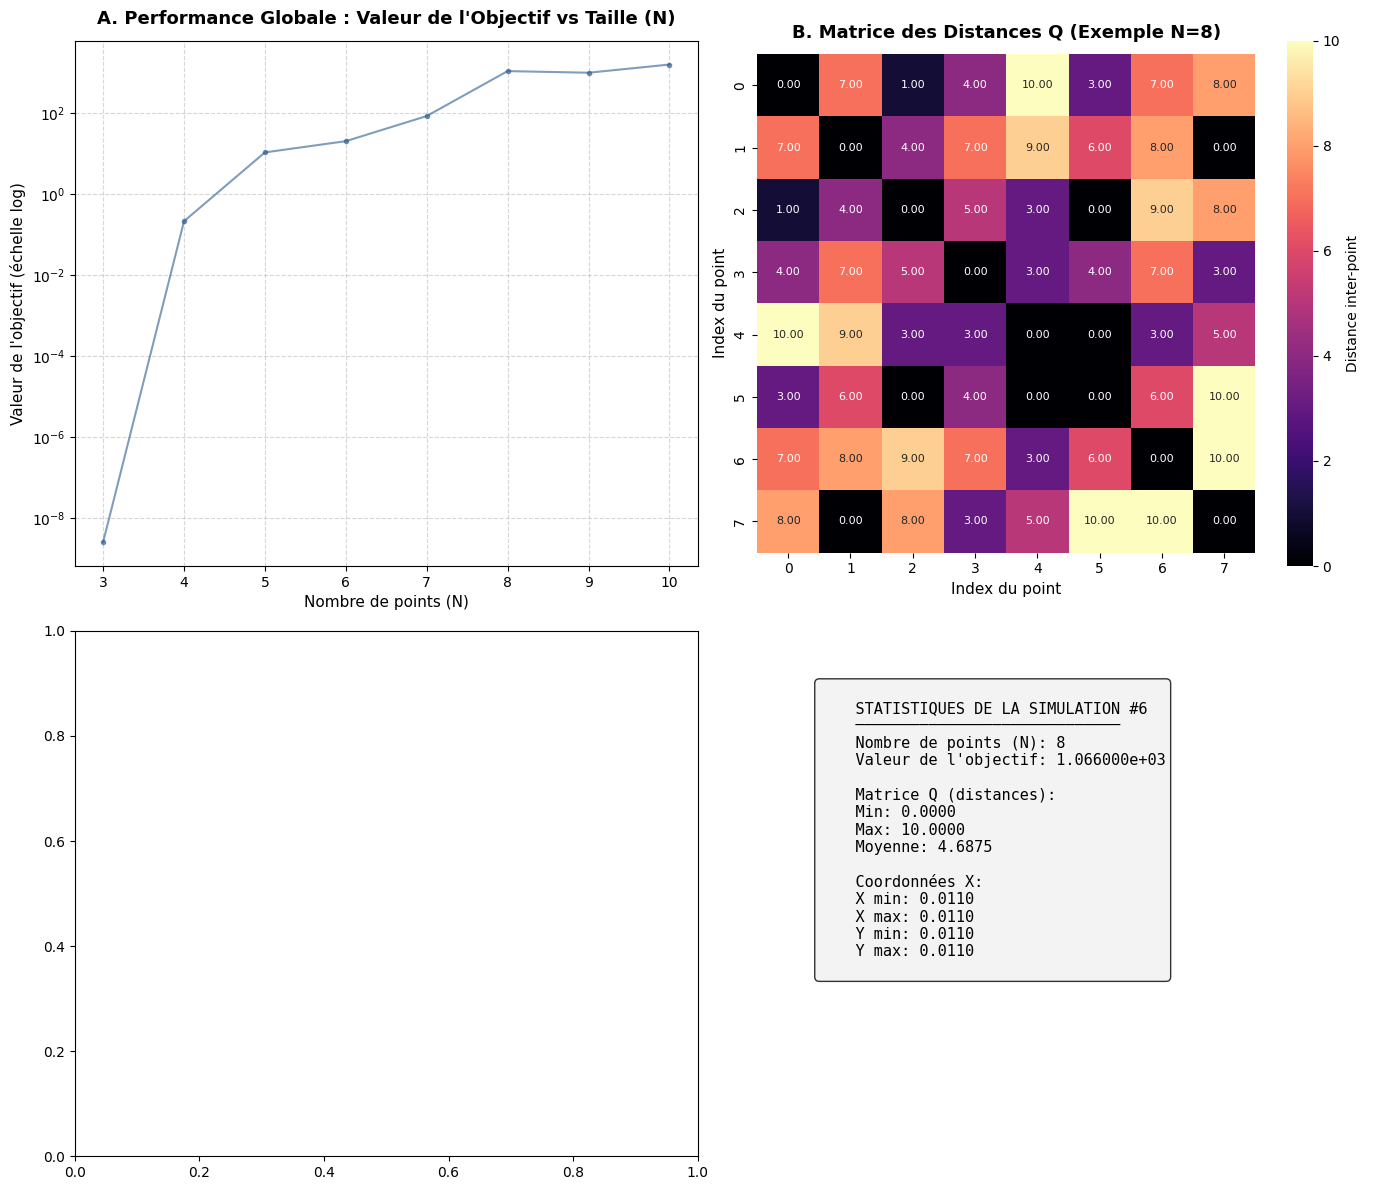

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def parse_optimization_results(filename):
    """Analyse le fichier de résultats textuels et extrait les structures de données (results1.csv)."""
    with open(filename, 'r', encoding='utf-8') as f:
        content = f.read()
    
    sections = content.split("-----------------------------------")
    parsed_sections = []
    
    def parse_array_matlab(s):
        """Parse MATLAB/Julia array format: [row1_vals; row2_vals; ...]"""
        s = s.strip().lstrip('[').rstrip(']')
        rows = []
        row_strs = s.split(';')
        for row_str in row_strs:
            vals = [float(x) for x in row_str.replace(',', ' ').split() if x.strip()]
            if vals:
                rows.append(vals)
        return np.array(rows) if rows else None

    for idx, sec in enumerate(sections):
        if 'Q =' in sec and 'objective_value' in sec and 'x =' in sec:
            try:
                data = {'index': idx}
                lines = sec.strip().split('\n')
                current_array = ""
                current_key = None
                
                for line in lines:
                    line = line.strip()
                    if not line:
                        continue
                    
                    if 'Q =' in line:
                        if current_key and current_array:
                            arr = parse_array_matlab(current_array)
                            if arr is not None:
                                data[current_key] = arr
                        current_key = 'Q'
                        current_array = line.split('=', 1)[1].strip()
                    elif 'objective_value =' in line:
                        if current_key and current_array:
                            arr = parse_array_matlab(current_array)
                            if arr is not None:
                                data[current_key] = arr
                        current_key = None
                        data['obj'] = float(line.split('=', 1)[1].strip())
                    elif 'x =' in line:
                        if current_key and current_array:
                            arr = parse_array_matlab(current_array)
                            if arr is not None:
                                data[current_key] = arr
                        current_key = 'x'
                        current_array = line.split('=', 1)[1].strip()
                    else:
                        if current_key:
                            current_array += " " + line
                
                if current_key and current_array:
                    arr = parse_array_matlab(current_array)
                    if arr is not None:
                        data[current_key] = arr
                
                if data.get('Q') is not None and data.get('x') is not None and data.get('obj') is not None:
                    parsed_sections.append(data)
            except Exception:
                pass
                
    return parsed_sections

# --- 1. Chargement et extraction des données ---
filename = 'results1.csv'
parsed_data = parse_optimization_results(filename)
print(f"Nombre de simulations chargées avec succès : {len(parsed_data)}")

if len(parsed_data) > 0:
    # Données globales pour les courbes de tendance
    num_points = [p['x'].shape[0] for p in parsed_data]
    obj_values = [p['obj'] for p in parsed_data]

    # --- 2. Sélection d'une simulation pour l'affichage détaillé ---
    sample_idx = min(5, len(parsed_data) - 1)
    sample_sec = parsed_data[sample_idx]
    Q_sample = sample_sec['Q']
    X_sample = sample_sec['x']
    obj_sample = sample_sec['obj']
    N_sample = X_sample.shape[0]

    # --- 3. Construction du Dashboard Multi-panel ---
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))

    # Graphique A : Évolution de la performance
    axes[0, 0].plot(num_points, obj_values, color='#2b5c8f', marker='o', markersize=3, linestyle='-', alpha=0.6)
    axes[0, 0].set_yscale('log')
    axes[0, 0].set_title("A. Performance Globale : Valeur de l'Objectif vs Taille (N)", fontsize=13, fontweight='bold', pad=12)
    axes[0, 0].set_xlabel("Nombre de points (N)", fontsize=11)
    axes[0, 0].set_ylabel("Valeur de l'objectif (échelle log)", fontsize=11)
    axes[0, 0].grid(True, which="both", linestyle="--", alpha=0.5)

    # Graphique B : Heatmap de la matrice Q
    sns.heatmap(Q_sample, ax=axes[0, 1], cmap='magma', annot=True, fmt=".2f", square=True,
                cbar_kws={'label': 'Distance inter-point'}, annot_kws={"size": 8})
    axes[0, 1].set_title(f"B. Matrice des Distances Q (Exemple N={N_sample})", fontsize=13, fontweight='bold', pad=12)
    axes[0, 1].set_xlabel("Index du point", fontsize=11)
    axes[0, 1].set_ylabel("Index du point", fontsize=11)

    # Graphique D : Statistiques
    axes[1, 1].axis('off')
    stats_text = f"""
    STATISTIQUES DE LA SIMULATION #{sample_idx+1}
    ─────────────────────────────
    Nombre de points (N): {N_sample}
    Valeur de l'objectif: {obj_sample:.6e}
    
    Matrice Q (distances):
    Min: {Q_sample.min():.4f}
    Max: {Q_sample.max():.4f}
    Moyenne: {Q_sample.mean():.4f}
    
    Coordonnées X:
    X min: {X_sample.min():.4f}
    X max: {X_sample.max():.4f}
    Y min: {X_sample[:, 1].min():.4f}
    Y max: {X_sample[:, 1].max():.4f}
    """
    axes[1, 1].text(0.1, 0.9, stats_text, transform=axes[1, 1].transAxes, fontsize=11, 
                   verticalalignment='top', fontfamily='monospace',
                   bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.8))

    # --- 4. Ajustement final et sauvegarde ---
    plt.tight_layout()
    plt.savefig('dashboard_results_optimization_form2.png', dpi=300)
    print("Le graphique a été correctement généré et sauvegardé sous 'dashboard_results_optimization_form2.png'.")
else:
    print("Aucune simulation chargée depuis results1.csv")